In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

# 1. Load the cleaned datasets
loan = pd.read_csv(r'../CleanData/clean_loan.csv', sep=';')
trans = pd.read_csv(r'../CleanData/clean_trans.csv', sep=';', low_memory=False)

# 2. Standardize join keys as strings
loan['account_id'] = loan['account_id'].astype(str)
loan['loan_id'] = loan['loan_id'].astype(str)
trans['account_id'] = trans['account_id'].astype(str)
trans['trans_id'] = trans['trans_id'].astype(str)

# 3. Ensure date columns are formatted as datetime
loan['loan_date'] = pd.to_datetime(loan['date'])
trans['trans_date'] = pd.to_datetime(trans['date'])

# 4. Join transactions with loan details on account_id
# Select the necessary loan columns to avoid duplicate column name collisions
loan_cols = ['account_id', 'loan_id', 'loan_date', 'amount', 'duration', 'payments', 'status', 'target']

trans_loan = pd.merge(
    trans,
    loan[loan_cols],
    on='account_id',
    how='inner',
    suffixes=('_trans', '_loan')
)

# 5. Filter for PRE-LOAN transactions (strictly before the loan grant date)
pre_loan_trans = trans_loan[trans_loan['trans_date'] < trans_loan['loan_date']].copy()

# Add a helper column for days before loan issuance
pre_loan_trans['days_before_loan'] = (pre_loan_trans['loan_date'] - pre_loan_trans['trans_date']).dt.days

# Verify the output
print(f"Total transactions merged: {len(trans_loan):,}")
print(f"Pre-loan transactions: {len(pre_loan_trans):,}")
print(f"Unique loans represented: {pre_loan_trans['loan_id'].nunique()}")

pre_loan_trans.head()

Total transactions merged: 191,556
Pre-loan transactions: 54,694
Unique loans represented: 682


,trans_id,account_id,date,type,operation,amount_trans,balance,k_symbol,trans_date,loan_id,loan_date,amount_loan,duration,payments,status,target,days_before_loan
0,1548749,5270,1993-01-13,credit,credit_in_cash,800.0,800.0,other_unknown,1993-01-13,6077,1993-11-22,79608.0,24,3317.0,A,0,313
1,1548750,5270,1993-01-14,credit,collection_other_bank,44749.0,45549.0,other_unknown,1993-01-14,6077,1993-11-22,79608.0,24,3317.0,A,0,312
2,3669814,5270,1993-01-31,credit,other_unknown,110.2,45659.2,interest_credited,1993-01-31,6077,1993-11-22,79608.0,24,3317.0,A,0,295
3,1549098,5270,1993-02-12,withdrawal,withdrawal_in_cash,9600.0,36059.2,other_unknown,1993-02-12,6077,1993-11-22,79608.0,24,3317.0,A,0,283
4,1548751,5270,1993-02-14,credit,collection_other_bank,44749.0,80808.2,other_unknown,1993-02-14,6077,1993-11-22,79608.0,24,3317.0,A,0,281


In [4]:
# ---------------------------------------------------------
# Step 1: Base Loan Metadata (1 row per loan)
# ---------------------------------------------------------
base_loans = (
    pre_loan_trans[['loan_id', 'account_id', 'loan_date', 'amount_loan', 'duration', 'payments', 'status', 'target']]
    .drop_duplicates(subset=['loan_id'])
    .set_index('loan_id')
)

# ---------------------------------------------------------
# Step 2: Aggregate Historical Cashflow & Balances
# ---------------------------------------------------------
balance_stats = pre_loan_trans.groupby('loan_id').agg(
    min_balance=('balance', 'min'),
    mean_balance=('balance', 'mean'),
    std_balance=('balance', 'std'),
    total_tx_count=('balance', 'count'),
    history_days=('days_before_loan', 'max')
)

# Cash inflow vs outflow volumes
cashflow_totals = (
    pre_loan_trans.pivot_table(
        index='loan_id',
        columns='type',
        values='amount_trans',
        aggfunc='sum',
        fill_value=0
    )
    .rename(columns={'credit': 'total_inflow', 'withdrawal': 'total_outflow'})
)

# ---------------------------------------------------------
# Step 3: 90-Day and 180-Day Window Indicators
# ---------------------------------------------------------
# 90-day window
tx_90d = pre_loan_trans[pre_loan_trans['days_before_loan'] <= 90]
balance_90d = tx_90d.groupby('loan_id').agg(
    min_balance_90d=('balance', 'min'),
    mean_balance_90d=('balance', 'mean')
)

# 180-day window (6 months prior to loan)
tx_180d = pre_loan_trans[pre_loan_trans['days_before_loan'] <= 180]
balance_180d = tx_180d.groupby('loan_id').agg(
    min_balance_180d=('balance', 'min'),
    mean_balance_180d=('balance', 'mean')
)

# ---------------------------------------------------------
# Step 4: Join All Features and Compute Trend Ratios
# ---------------------------------------------------------
eda_loans = base_loans.join([
    balance_stats, 
    cashflow_totals, 
    balance_90d, 
    balance_180d
]).fillna(0)

# Approximate monthly net salary/inflow
eda_loans['months_history'] = (eda_loans['history_days'] / 30.4).clip(lower=1)
eda_loans['avg_monthly_inflow'] = eda_loans['total_inflow'] / eda_loans['months_history']

# Debt-Service-to-Income (DSTI) proxy
eda_loans['dsti_ratio'] = eda_loans['payments'] / (eda_loans['avg_monthly_inflow'] + 1e-5)

# Recent liquidity drop indicators
# 1. 90-day trend vs overall mean
eda_loans['balance_trend_90d'] = eda_loans['mean_balance_90d'] / (eda_loans['mean_balance'] + 1e-5)

# 2. 180-day trend vs overall mean
eda_loans['balance_trend_180d'] = eda_loans['mean_balance_180d'] / (eda_loans['mean_balance'] + 1e-5)

# 3. Acceleration/Deterioration (Last 3 months vs Last 6 months)
eda_loans['balance_trend_90d_vs_180d'] = eda_loans['mean_balance_90d'] / (eda_loans['mean_balance_180d'] + 1e-5)

print("Columns added:")
print([col for col in eda_loans.columns if '180d' in col])

Columns added:
['min_balance_180d', 'mean_balance_180d', 'balance_trend_180d', 'balance_trend_90d_vs_180d']


In [5]:
# Aggregate total transaction amounts by transaction purpose (k_symbol)
k_symbol_spend = pre_loan_trans.pivot_table(
    index='loan_id',
    columns='k_symbol',
    values='amount_trans',
    aggfunc='sum',
    fill_value=0
)

# Prefix columns cleanly
k_symbol_spend.columns = [f'k_sym_{col.strip().lower()}' for col in k_symbol_spend.columns]

# Aggregate count of electronic payroll collections vs cash deposits
ops_counts = pre_loan_trans.pivot_table(
    index='loan_id',
    columns='operation',
    values='amount_trans',
    aggfunc='count',
    fill_value=0
)
ops_counts.columns = [f'op_count_{col.strip().lower()}' for col in ops_counts.columns]

# Join back to our master loan modeling dataframe
master_eda = eda_loans.join([k_symbol_spend, ops_counts]).fillna(0)

print(f"Final modeling & EDA dataset shape: {master_eda.shape}")
print("\nNew category columns added:")
print(list(k_symbol_spend.columns) + list(ops_counts.columns))

Final modeling & EDA dataset shape: (682, 36)

New category columns added:
['k_sym_household_payment', 'k_sym_insurance_payment', 'k_sym_interest_credited', 'k_sym_other_unknown', 'k_sym_sanction_interest', 'k_sym_statement_payment', 'op_count_collection_other_bank', 'op_count_credit_card_withdrawal', 'op_count_credit_in_cash', 'op_count_other_unknown', 'op_count_remittance_to_other_bank', 'op_count_withdrawal_in_cash']


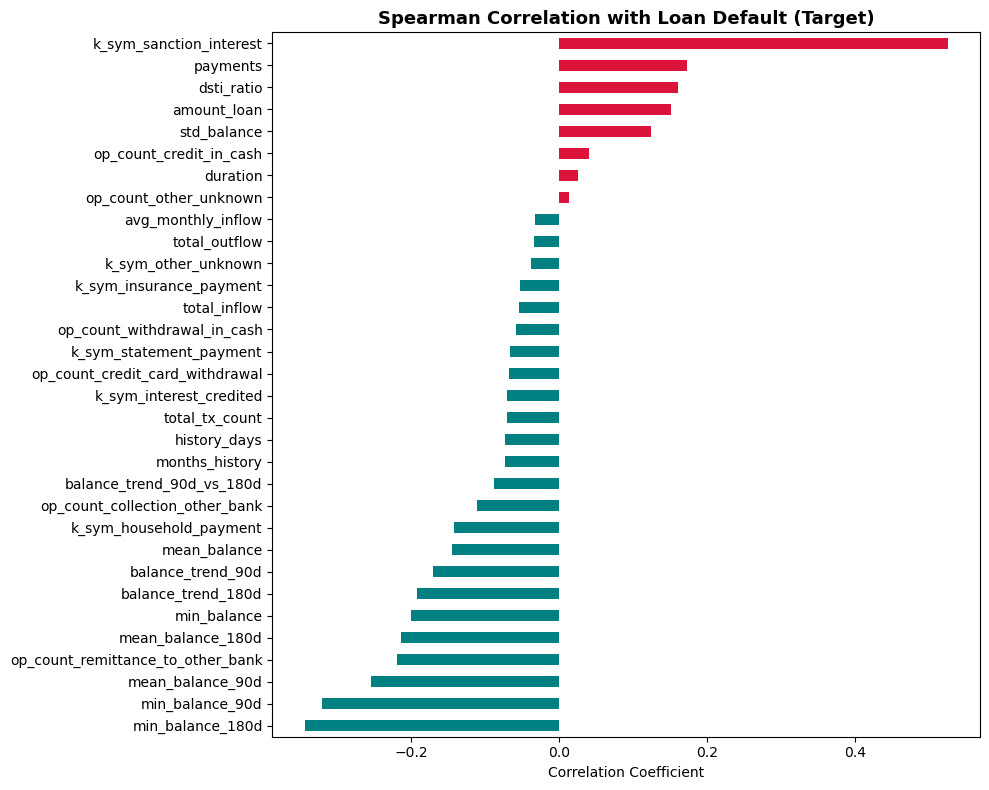

In [6]:
# Calculate Spearman (rank) correlation with default target
numeric_cols = master_eda.select_dtypes(include=[np.number]).columns
corr_series = master_eda[numeric_cols].corr(method='spearman')['target'].sort_values()

plt.figure(figsize=(10, 8))
corr_series.drop('target').plot(kind='barh', color=np.where(corr_series.drop('target') > 0, 'crimson', 'teal'))
plt.title('Spearman Correlation with Loan Default (Target)', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

In [7]:
master_eda

,account_id,loan_date,amount_loan,duration,payments,status,target,min_balance,mean_balance,std_balance,...,k_sym_interest_credited,k_sym_other_unknown,k_sym_sanction_interest,k_sym_statement_payment,op_count_collection_other_bank,op_count_credit_card_withdrawal,op_count_credit_in_cash,op_count_other_unknown,op_count_remittance_to_other_bank,op_count_withdrawal_in_cash
loan_id,,,,,,,,,,,,,,,,,,,,,
6077,5270,1993-11-22,79608.0,24,3317.0,A,0,800.0,69954.571698,24870.232928,...,2868.4,929863.0,0.0,87.6,11,0,1,10,0,31
7284,11265,1993-09-15,52788.0,12,4399.0,A,0,1000.0,22198.179070,6652.642956,...,631.8,157041.0,0.0,43.8,0,0,14,7,8,14
7121,10364,1993-11-10,21924.0,36,609.0,A,0,1100.0,34272.213333,10171.031846,...,1110.0,235596.5,0.0,73.0,0,0,12,9,5,19
5754,3834,1994-09-28,23052.0,12,1921.0,A,0,700.0,23771.966082,8912.019358,...,1921.8,522048.0,0.0,219.0,0,0,29,19,61,62
6895,9307,1994-09-19,41904.0,12,3492.0,A,0,900.0,36080.386713,20303.817120,...,4302.8,886757.0,0.0,219.0,0,0,26,37,30,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6872,9227,1998-04-29,191580.0,60,3193.0,C,0,900.0,18241.440000,6812.897166,...,628.3,66477.0,0.0,14.6,0,0,10,10,4,6
7035,10005,1998-07-29,210744.0,36,5854.0,C,0,200.0,51175.192308,20060.060760,...,1324.9,565557.0,0.0,43.8,8,0,1,7,4,19
5027,276,1998-12-02,160920.0,36,4470.0,C,0,700.0,51649.398305,16029.138294,...,2820.8,616691.0,0.0,116.8,12,0,1,12,7,27


--- Default Rate by Cash Reliance ---
cash_bucket
(0.00028870609584, 0.041424042411]     4.093567
(0.041424042411, 0.99999999995]       14.705882
(0.99999999995, 0.99999999997]        12.941176
(0.99999999997, 0.99999999999]        12.865497
Name: target, dtype: float64


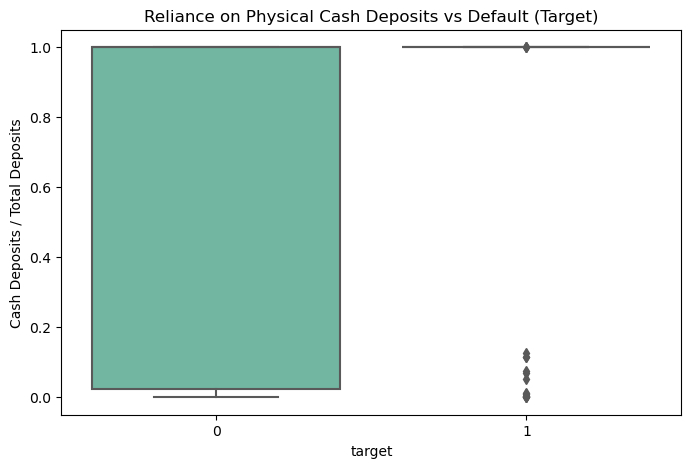

In [8]:
# 1. Separate regular salary from physical cash deposits
income_modes = pre_loan_trans.pivot_table(
    index='loan_id',
    columns='operation',
    values='amount_trans',
    aggfunc='sum',
    fill_value=0
)

salary_eda = base_loans.copy()
salary_eda['salary_electronic'] = income_modes.get('collection_other_bank', 0)
salary_eda['cash_deposits'] = income_modes.get('credit_in_cash', 0)
salary_eda['total_inflows'] = salary_eda['salary_electronic'] + salary_eda['cash_deposits'] + 1e-5

salary_eda['cash_reliance_ratio'] = salary_eda['cash_deposits'] / salary_eda['total_inflows']

salary_eda['cash_bucket'] = pd.qcut(salary_eda['cash_reliance_ratio'], q=4, duplicates='drop')
print("--- Default Rate by Cash Reliance ---")
print(salary_eda.groupby('cash_bucket', observed=False)['target'].mean() * 100)

plt.figure(figsize=(8, 5))
sns.boxplot(data=salary_eda, x='target', y='cash_reliance_ratio', palette='Set2')
plt.title('Reliance on Physical Cash Deposits vs Default (Target)')
plt.ylabel('Cash Deposits / Total Deposits')
plt.show()

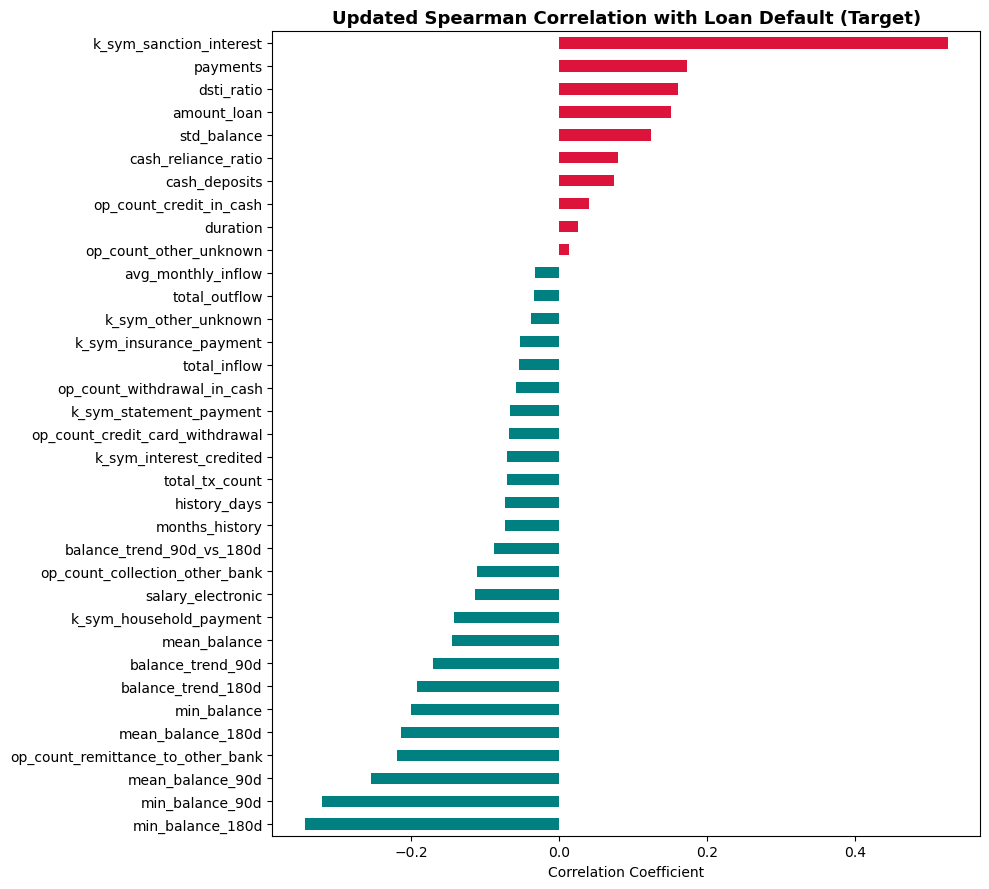

Spearman correlation for cash_reliance_ratio: 0.0798


In [9]:
# 1. Compute cash reliance ratio from pre-loan transactions
income_ops = pre_loan_trans.pivot_table(
    index='loan_id',
    columns='operation',
    values='amount_trans',
    aggfunc='sum',
    fill_value=0
)

# 2. Add cash reliance directly to your master table
master_eda['salary_electronic'] = income_ops.get('collection_other_bank', 0)
master_eda['cash_deposits'] = income_ops.get('credit_in_cash', 0)
master_eda['cash_reliance_ratio'] = master_eda['cash_deposits'] / (master_eda['cash_deposits'] + master_eda['salary_electronic'] + 1e-5)

# 3. Re-calculate Spearman rank correlation
numeric_cols = master_eda.select_dtypes(include=[np.number]).columns
corr_series = master_eda[numeric_cols].corr(method='spearman')['target'].sort_values()

# 4. Re-plot the bar chart
plt.figure(figsize=(10, 9))
corr_series.drop('target').plot(
    kind='barh', 
    color=np.where(corr_series.drop('target') > 0, 'crimson', 'teal')
)
plt.title('Updated Spearman Correlation with Loan Default (Target)', fontsize=13, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

# Print its exact rank and value
print(f"Spearman correlation for cash_reliance_ratio: {corr_series['cash_reliance_ratio']:.4f}")

In [10]:
# Ensure cash_reliance_ratio is added to the primary table
master_eda['cash_reliance_ratio'] = salary_eda['cash_reliance_ratio']

In [11]:
# Save the engineered transaction feature table for downstream use
output_path = '../modelData/features_transaction.csv'
master_eda.to_csv(output_path)
print(f"Engineered dataset saved successfully to {output_path} with shape {master_eda.shape}")

Engineered dataset saved successfully to ../modelData/features_transaction.csv with shape (682, 39)
